## Cervical Cancer - Supervised model benchmark after feature selection

### The purpose of this notebook is to compare several supervised ML methods for the prediction of biopsy outcome. Model selection is performed on the training data using 5-time stratified cross-validation. The held-out test set is not used at this stage and will be reserved for final model evaluation.

Two predition settings are considered : 
1. **Selected risk-factor features**
2. **Selected risk-factor features + screening tests** (`Hinselmann`, `Schiller`, `Citology`)

### 1. Import libraries + training data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import make_scorer, precision_score, matthews_corrcoef
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

SELECTED_DIR = Path("../01_DATA/selected")
PLOTS_DIR = Path("../04_FIGURES")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR = Path("../05_RESULTS")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


risk_train = pd.read_csv(SELECTED_DIR / "x_train_selected.csv")
diag_train = pd.read_csv(SELECTED_DIR / "diag_x_train_selected.csv")

y_risk = risk_train["Biopsy"]
X_risk = risk_train.drop(columns="Biopsy")

y_diag = diag_train["Biopsy"]
X_diag = diag_train.drop(columns="Biopsy")

assert y_risk.equals(y_diag) #to make sure they have the same target
y = y_risk

print("\n Risk-factor dataset:", X_risk.shape)
print("\n Diagnostic-inclusive dataset:", X_diag.shape)
print("\n Target distribution:")
print(y.value_counts())

NB : Feature selection included RFECV based on a logistic regression estimator. Therefore, the selected subset may partly favour linear models.

### 2. Cross-validation + models tests parameters + scoring

In [26]:
RANDOM_STATE = 28 #random state added to make reproctubility possible, and use the same random state in every tests
cv = RepeatedStratifiedKFold(n_splits = 5, n_repeats = 5, random_state = RANDOM_STATE)

Repeated stratified 5-fold was used to preserve the proportion of positive and negative biopsy outcome in each fold and to obtain a more robust estimate of model performance.

In [27]:
models = {"Dummy": DummyClassifier(strategy="prior", random_state=RANDOM_STATE),
          "Logistic Regression": Pipeline([("scaler", StandardScaler()), ("classifier", LogisticRegression(class_weight="balanced", max_iter=5000, random_state=RANDOM_STATE))]),
          "Decision Tree": DecisionTreeClassifier(class_weight="balanced", max_depth=4, random_state=RANDOM_STATE),
          "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE,),
          "SVM": Pipeline([("scaler", StandardScaler()), ("classifier", SVC(kernel="rbf", class_weight="balanced", random_state=RANDOM_STATE))]),
          "XGBoost": XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05,subsample=0.8, scale_pos_weight=(y == 0).sum() / (y == 1).sum(), random_state=RANDOM_STATE,)}

For Logistic Regression and SVM, as they need to be standardized, we use Pipeline for that.
scale_pos_weight was set to the negative-to-positive class ratio in order to account for class imbalance.

In [28]:
scoring = {"PR_AUC": "average_precision",
           "ROC_AUC": "roc_auc",
           "Recall": "recall",
           "Precision": make_scorer(precision_score, zero_division = 0), #to avoid having warnings output when the model predicts no positive
           "F1": "f1",
           "Balanced_accuracy": "balanced_accuracy",
           "MCC": make_scorer(matthews_corrcoef)}

In [29]:
def benchmark_models(X, y, models, cv, scoring):
    results = []
    for model_name, model in models.items():
        scores = cross_validate(model, X, y, cv = cv, scoring = scoring)
        row = {"Model": model_name}
        for metric in scoring:
            values = scores[f"test_{metric}"]
            row[f"{metric}_mean"] = values.mean()
            row[f"{metric}_std"] = values.std()
            row[f"{metric}_median"] = np.median(values)
            row[f"{metric}_min"] = values.min()
            row[f"{metric}_max"] = values.max()
        results.append(row)
    return pd.DataFrame(results)

We make a loop to test all the models at once and to keep the code as clean and concise as possible.

### 4. Benchmark (1) - Selected risk factors dataset

In [30]:
results_risk = benchmark_models(X_risk, y_risk, models, cv, scoring)
results_risk.round(3)

results_risk.to_csv(RESULTS_DIR / "benchmark_selected_risk_features.csv", index=False)

### 5. Benchmark (2) - Selected diagnostic dataset

In [31]:
results_full = benchmark_models(X_diag, y_diag, models, cv, scoring)
results_full.round(3)

results_full.to_csv(RESULTS_DIR / "benchmark_selected_diag_features.csv", index=False)

### 6. Table + box plot of metrics (PR-AUC and others)

In [36]:
def make_slide_table(results):

    table = pd.DataFrame({"Model": results["Model"],
                          "PR-AUC": (results["PR_AUC_mean"].round(3).astype(str)+ " ± " + results["PR_AUC_std"].round(3).astype(str)),
                          "MCC": (results["MCC_mean"].round(3).astype(str) + " ± " + results["MCC_std"].round(3).astype(str)),
                          "Recall": (results["Recall_mean"].round(3).astype(str) + " ± " + results["Recall_std"].round(3).astype(str)),
                          "Precision": (results["Precision_mean"].round(3).astype(str) + " ± " + results["Precision_std"].round(3).astype(str)),
                          "F1": (results["F1_mean"].round(3).astype(str) + " ± " + results["F1_std"].round(3).astype(str)),
                          "Balanced Acc.": (results["Balanced_accuracy_mean"].round(3).astype(str) + " ± " + results["Balanced_accuracy_std"].round(3).astype(str)),
                          "ROC-AUC": (results["ROC_AUC_mean"].round(3).astype(str) + " ± " + results["ROC_AUC_std"].round(3).astype(str))})
    return table
slide_table_risk = make_slide_table(results_risk)
print(slide_table_risk)
slide_table_risk.to_csv(RESULTS_DIR / "slide_table_risk.csv", index=False)

slide_table_diag = make_slide_table(results_full)
print(slide_table_diag)
slide_table_diag.to_csv(RESULTS_DIR / "slide_table_diag.csv", index=False)

                 Model         PR-AUC             MCC         Recall  \
0                Dummy  0.065 ± 0.004       0.0 ± 0.0      0.0 ± 0.0   
1  Logistic Regression  0.121 ± 0.047   0.067 ± 0.107  0.326 ± 0.149   
2        Decision Tree  0.106 ± 0.048   0.078 ± 0.106  0.249 ± 0.162   
3        Random Forest  0.077 ± 0.024  -0.005 ± 0.067  0.174 ± 0.114   
4                  SVM  0.106 ± 0.053  -0.024 ± 0.075   0.114 ± 0.11   
5              XGBoost  0.079 ± 0.021  -0.024 ± 0.083  0.147 ± 0.101   

       Precision             F1  Balanced Acc.        ROC-AUC  
0      0.0 ± 0.0      0.0 ± 0.0      0.5 ± 0.0      0.5 ± 0.0  
1  0.103 ± 0.046  0.152 ± 0.067  0.551 ± 0.096  0.569 ± 0.113  
2   0.13 ± 0.091  0.152 ± 0.087  0.545 ± 0.065  0.584 ± 0.077  
3   0.06 ± 0.039  0.089 ± 0.057   0.499 ± 0.05  0.462 ± 0.082  
4  0.051 ± 0.047  0.069 ± 0.062  0.482 ± 0.055  0.575 ± 0.096  
5   0.06 ± 0.054   0.08 ± 0.061  0.475 ± 0.062  0.492 ± 0.106  
                 Model         PR-AUC          

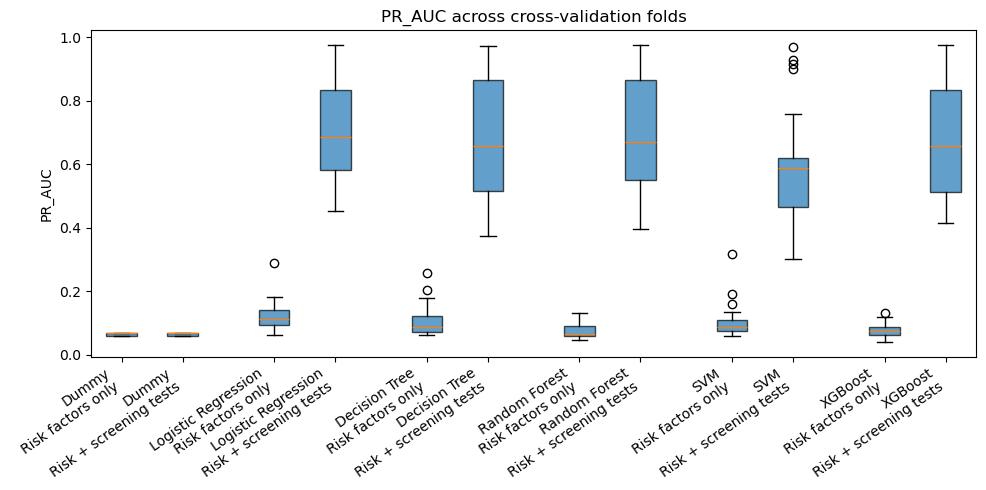

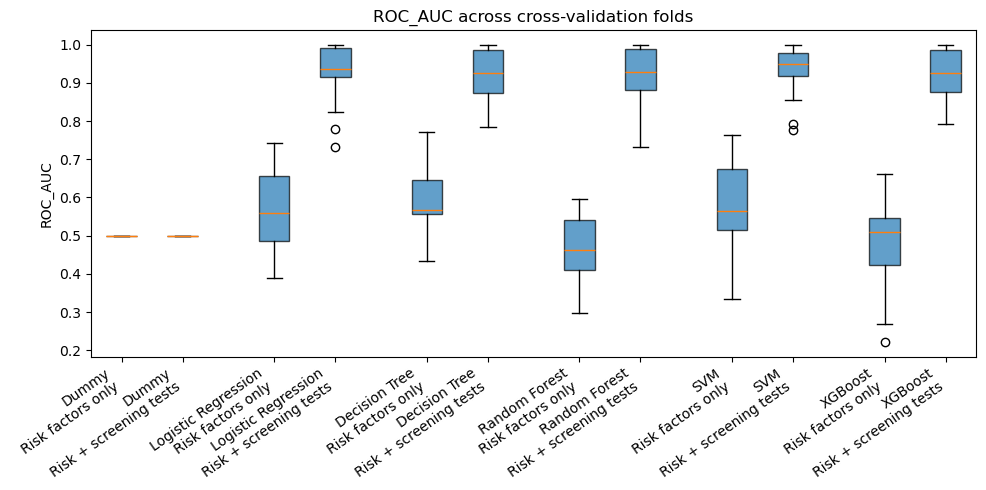

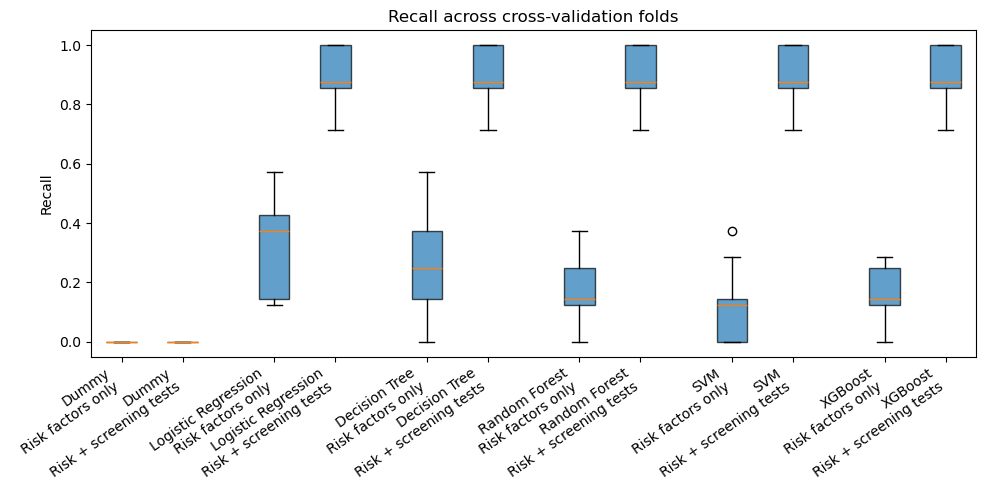

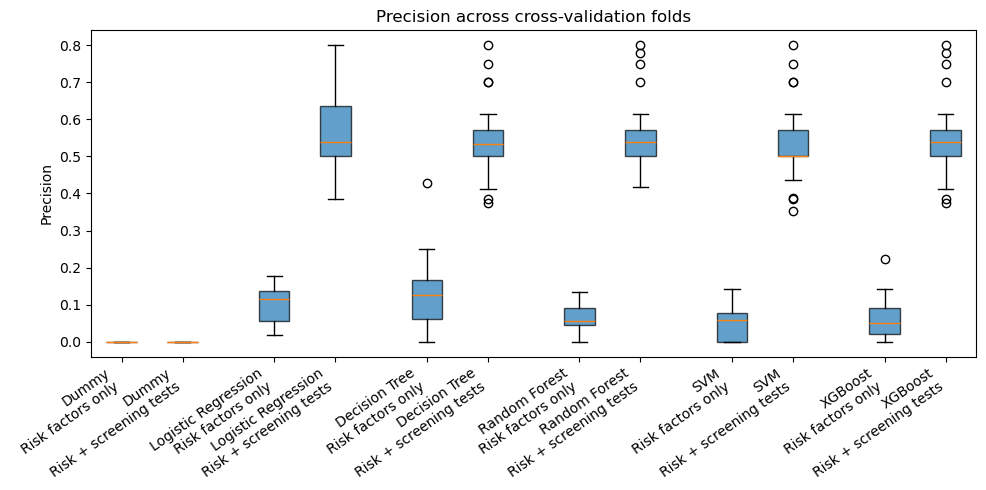

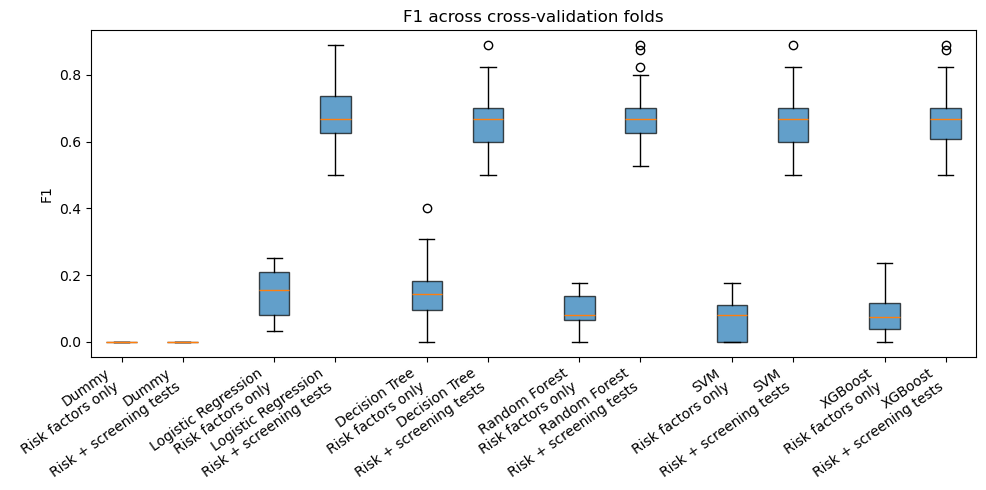

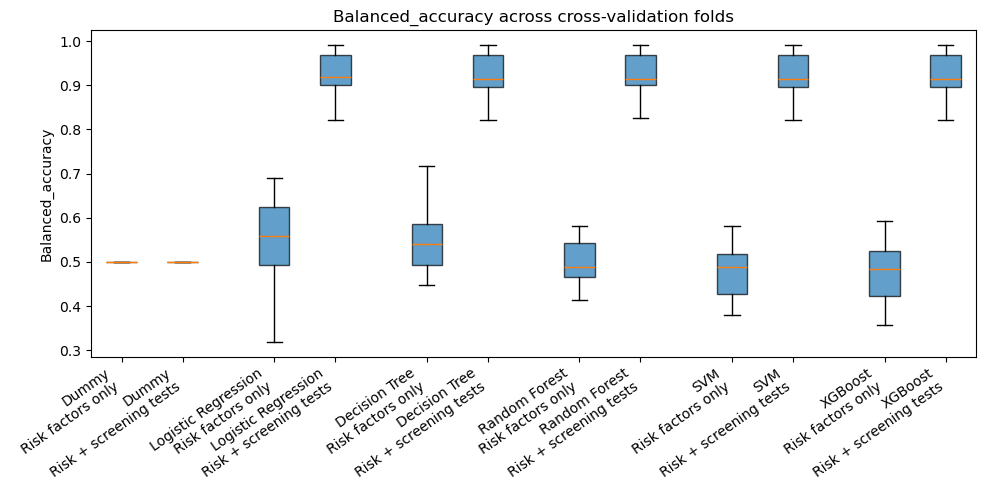

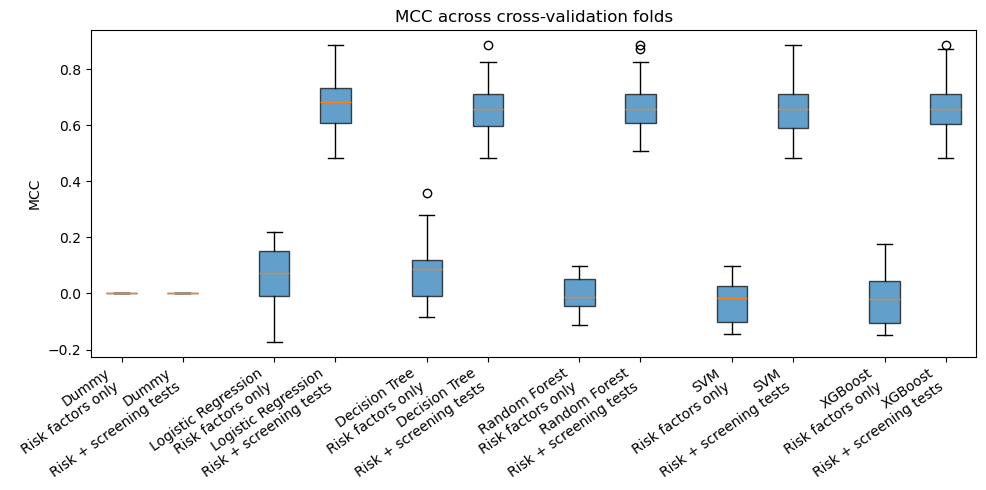

In [37]:
datasets = {"Risk factors only": X_risk, "Risk + screening tests": X_diag}

all_scores = []

for scenario, X in datasets.items():
    for model_name, model in models.items():
        scores = cross_validate(model, X, y, cv=cv, scoring=scoring)
        for metric in scoring:
            for value in scores[f"test_{metric}"]:
                all_scores.append({"Scenario": scenario, "Model": model_name, "Metric": metric, "Score": value})

scores_df = pd.DataFrame(all_scores)

summary = (scores_df.groupby(["Scenario", "Metric", "Model"])["Score"].agg(["mean", "std", "median", "min", "max"]).round(3))
summary
summary.to_csv(RESULTS_DIR / "benchmark_summary_all_metrics.csv")

for metric in scoring:
    data = scores_df[scores_df["Metric"] == metric]
    fig, ax = plt.subplots(figsize=(10, 5))
    positions = []
    values = []
    labels = []

    pos = 1

    for model in data["Model"].unique():
        for scenario in data["Scenario"].unique():

            vals = data.loc[(data["Model"] == model) & (data["Scenario"] == scenario), "Score"].values
            values.append(vals)
            positions.append(pos)
            labels.append(f"{model}\n{scenario}")
            pos += 1
        pos += 0.5
    bp = ax.boxplot(values, positions=positions, patch_artist=True)

    for box in bp["boxes"]:
        box.set_alpha(0.7)

    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=35, ha="right")
    ax.set_title(f"{metric} across cross-validation folds")
    ax.set_ylabel(metric)

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"{metric}_boxplot_risk_vs_diag.png", dpi=300, bbox_inches="tight")
    plt.show()

The baseline classifier (Dummy) failed to identify positive biopsy cases in several validation folds, illustrating the limitations of threshold-based metrics in this highly imbalanced dataset.

PR-AUC remains particularly useful here because it utilizes scores/probabilities across all thresholds, rather than relying solely on a classification threshold like 0.5. That's why it can be choosed as the primary metric.

Based on predictive performance, stability, interpretability and complementarity of modelling assumptions, we selected Logistic Regression and Random Forest for further analysis.

### 7. Confusion matrix

Confusion matrices were generated from out-of-fold predictions using stratified cross-validation. They are presented as an exploratory complement to PR-AUC, MCC and other cross-validated metrics, rather than as the primary model-selection criterion.

In [ ]:
cv_cm = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

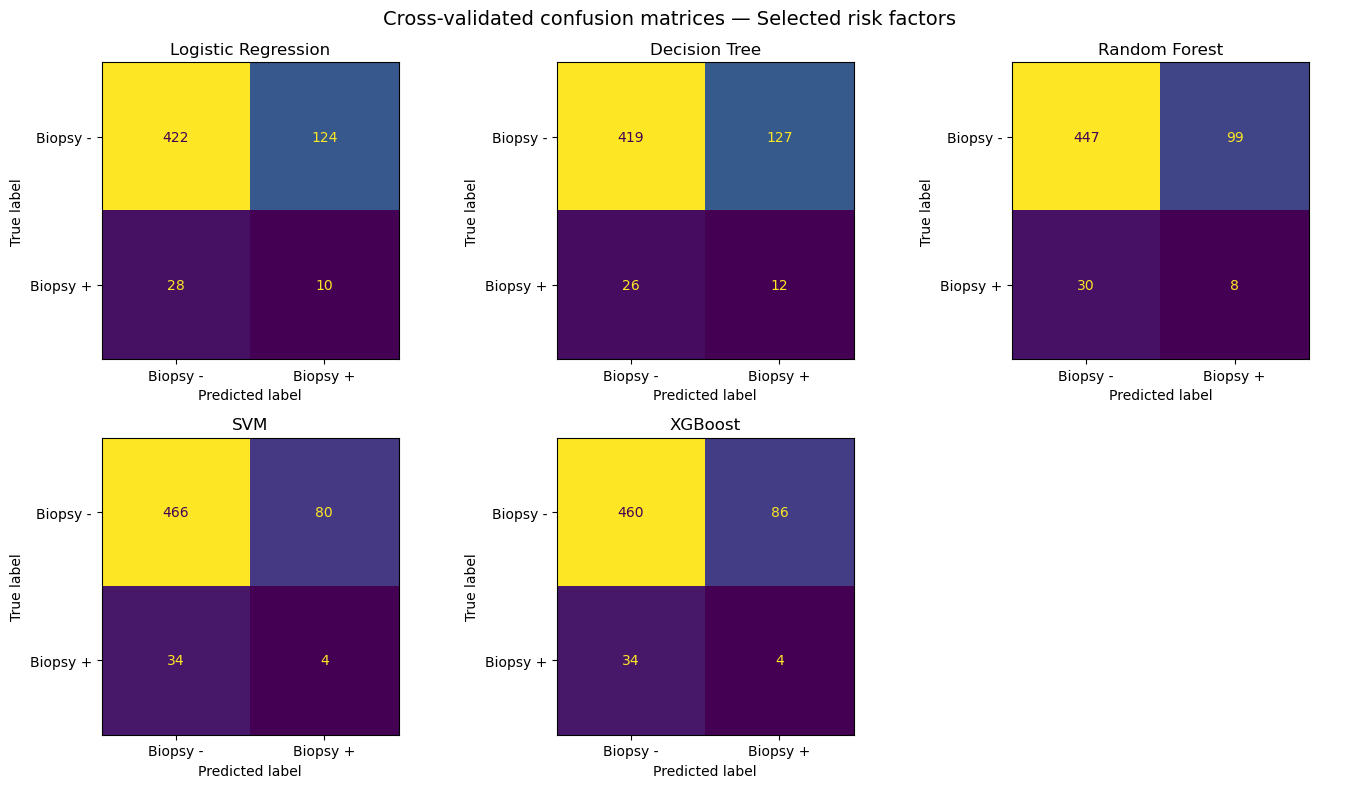

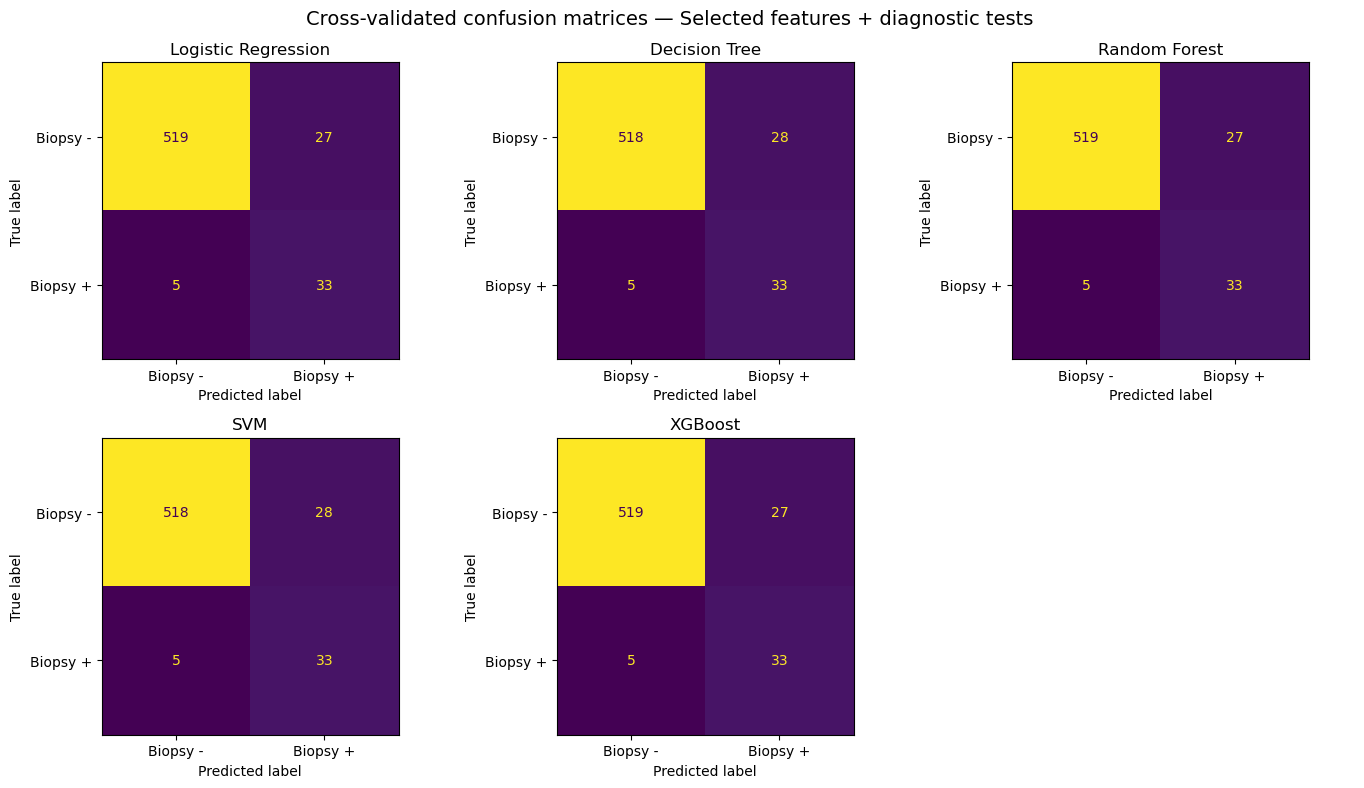

In [ ]:
models_cm = {name: model
for name, model in models.items()
    if name != "Dummy"}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, (model_name, model) in zip(axes, models_cm.items()):
    y_pred = cross_val_predict(model, X_risk, y_risk, cv=cv_cm, method="predict",)
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Biopsy -", "Biopsy +"])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(model_name)

# Hide unused subplots
for ax in axes[len(models_cm):]:
    ax.axis("off")

plt.suptitle("Cross-validated confusion matrices — Selected risk factors", fontsize=14)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "confusion_matrices_risk_models.png", dpi=300, bbox_inches="tight")
plt.show()

models_cm = {name: model
for name, model in models.items()
    if name != "Dummy"}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, (model_name, model) in zip(axes, models_cm.items()):
    y_pred = cross_val_predict(model, X_diag, y_diag, cv=cv_cm, method="predict",)
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Biopsy -", "Biopsy +"])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(model_name)

# Hide unused subplots
for ax in axes[len(models_cm):]:
    ax.axis("off")

plt.suptitle("Cross-validated confusion matrices — Selected features + diagnostic tests", fontsize=14)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "confusion_matrices_diagnostic_models.png", dpi=300, bbox_inches="tight")
plt.show()
